In [ ]:
# Nama Lengkap: Khairil Ramadhani
# NIM: 240401040511
# Kelas: IF405

Distribusi kelas sebelum SMOTE:
0    897
1    103
Name: count, dtype: int64

Distribusi kelas sesudah SMOTE (Training):
0    717
1    717
Name: count, dtype: int64

=== EVALUASI RANDOM FOREST + SMOTE ===
Accuracy  : 0.94
Precision : 0.7222222222222222
Recall    : 0.65
F1-Score  : 0.6842105263157895


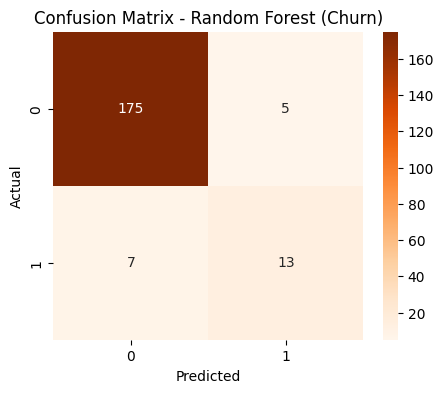

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

# Membuat simulasi dataset Churn yang tidak seimbang (Imbalanced Dataset)
X_synth, y_synth = make_classification(n_samples=1000, weights=[0.9, 0.1], random_state=42)
X = pd.DataFrame(X_synth, columns=[f"feature_{i}" for i in range(X_synth.shape[1])])
y = pd.Series(y_synth)

print("Distribusi kelas sebelum SMOTE:")
print(y.value_counts())

# Membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menangani imbalanced dataset menggunakan SMOTE pada data training
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDistribusi kelas sesudah SMOTE (Training):")
print(y_train_smote.value_counts())

# Melatih model Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_smote, y_train_smote)

# Melakukan prediksi
y_pred = rf_clf.predict(X_test)

# Evaluasi Performa Model
print("\n=== EVALUASI RANDOM FOREST + SMOTE ===")
print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1-Score  :", f1_score(y_test, y_pred))

# Visualisasi Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest (Churn)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Kesimpulan
- **Apa yang dipelajari:** Mempelajari metode *Ensemble Learning* (Random Forest) yang menggabungkan banyak *decision trees* serta cara mengatasi *imbalanced dataset* (seperti pada kasus *Customer Churn*) menggunakan teknik *oversampling* SMOTE.
- **Temuan utama:** Pada dataset *churn* yang tidak seimbang, nilai *Accuracy* saja bisa sangat menyesatkan (*Accuracy Paradox*). Penggunaan metrik **Recall** dan **F1-Score** jauh lebih krusial untuk memastikan pelanggan yang berpotensi *churn* dapat terdeteksi dengan akurat oleh sistem.
- **Keterbatasan / Pertanyaan:** Penggunaan SMOTE menciptakan data sintetis yang dapat berisiko memicu *overfitting* apabila tidak dievaluasi dengan cermat menggunakan teknik validasi silang (*cross-validation*).